In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('placement.csv')

In [3]:
df.shape

(1000, 3)

In [4]:
df.sample(5)

,cgpa,placement_exam_marks,placed
655,7.36,34.0,0
452,6.59,42.0,1
823,6.67,18.0,0
358,6.74,52.0,0
864,6.32,5.0,0


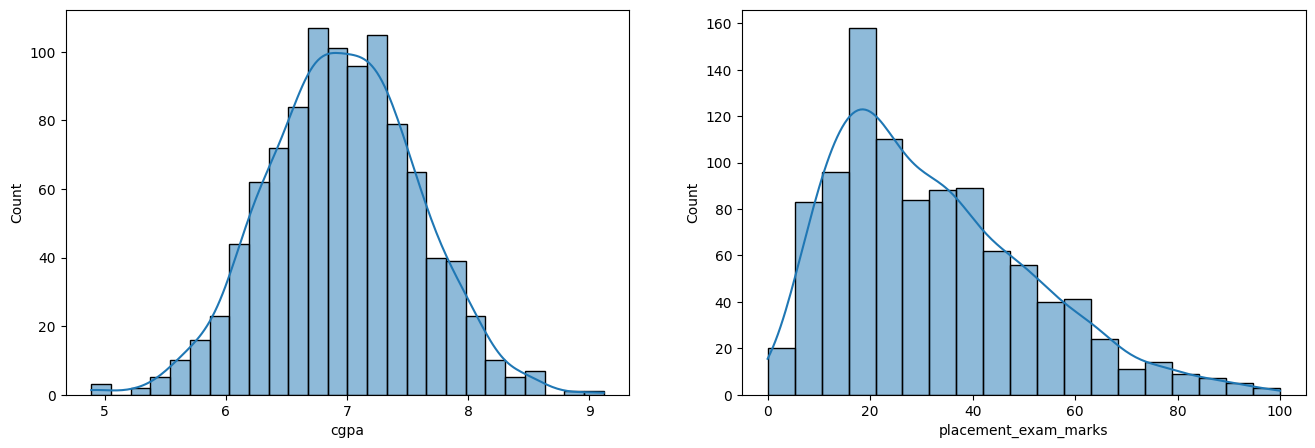

In [9]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(df['cgpa'], kde= True)

plt.subplot(1,2,2)
sns.histplot(df['placement_exam_marks'], kde = True)

plt.show()

In [10]:
df['placement_exam_marks'].skew()

0.8356419499466834

In [11]:
print("Mean value of cgpa",df['cgpa'].mean())
print("Std value of cgpa",df['cgpa'].std())
print("Min value of cgpa",df['cgpa'].min())
print("Max value of cgpa",df['cgpa'].max())

Mean value of cgpa 6.96124
Std value of cgpa 0.6158978751323896
Min value of cgpa 4.89
Max value of cgpa 9.12


In [13]:
# Finding the boundary values
print("Highest allowed CGPA ",df['cgpa'].mean() + 3*df['cgpa'].std())
print("Lowest allowed CGPA ",df['cgpa'].mean() - 3*df['cgpa'].std())

Highest allowed CGPA  8.808933625397168
Lowest allowed CGPA  5.113546374602832


In [14]:
# Finding the outliers
df[(df['cgpa'] > 8.80) | (df['cgpa'] < 5.11)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


## Trimming

In [15]:
# Trimming

new_df = df[(df['cgpa'] < 8.80) & (df['cgpa'] > 5.11)]
new_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


# Approach 2  -Calculating the Z-score

In [16]:
# z score formula 
df['cgpa_zscore'] = (df['cgpa'] - df['cgpa'].mean())/df['cgpa'].std()

In [17]:
df.head()

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


In [18]:
df[df['cgpa_zscore'] > 3]

,cgpa,placement_exam_marks,placed,cgpa_zscore
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062


In [19]:
df[df['cgpa_zscore'] < -3]

,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [20]:
# outliers
df[(df['cgpa_zscore'] > 3) | (df['cgpa_zscore'] < -3)]

,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [21]:
# Trimming 
new_df = df[(df['cgpa_zscore'] < 3) & (df['cgpa_zscore'] > -3)]

In [22]:
new_df

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371
...,...,...,...,...
991,7.04,57.0,0,0.127878
992,6.26,12.0,0,-1.138565
993,6.73,21.0,1,-0.375452
994,6.48,63.0,0,-0.781363


## Capping

In [23]:
upper_limit = df['cgpa'].mean() + 3*df['cgpa'].std()
lower_limit = df['cgpa'].mean() - 3*df['cgpa'].std()

In [24]:
lower_limit

5.113546374602832

In [25]:
df['cgpa'] = np.where(
    df['cgpa']>upper_limit,
    upper_limit,
    np.where(
        df['cgpa']<lower_limit,
        lower_limit,
        df['cgpa']
    )
)

In [26]:
df.shape

(1000, 4)

In [27]:
df['cgpa'].describe()

count    1000.000000
mean        6.961499
std         0.612688
min         5.113546
25%         6.550000
50%         6.960000
75%         7.370000
max         8.808934
Name: cgpa, dtype: float64

# detection and removal using IQR 

In [28]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: xlabel='placement_exam_marks'>

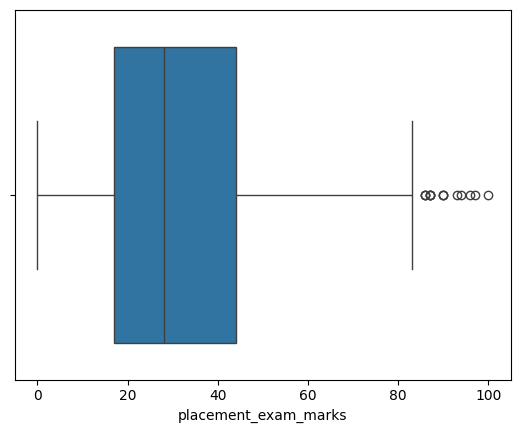

In [30]:
sns.boxplot( x = df['placement_exam_marks'])

In [31]:
# Finding the IQR
percentile25 = df['placement_exam_marks'].quantile(0.25)
percentile75 = df['placement_exam_marks'].quantile(0.75)

In [33]:
percentile25


17.0

In [34]:
percentile75

44.0

In [35]:
iqr = percentile75 - percentile25

In [36]:
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr

In [37]:
print("Upper limit",upper_limit)
print("Lower limit",lower_limit)

Upper limit 84.5
Lower limit -23.5


In [38]:
df[df['placement_exam_marks'] > upper_limit]

,cgpa,placement_exam_marks,placed,cgpa_zscore
9,7.75,94.0,1,1.280667
40,6.60,86.0,1,-0.586526
61,7.51,86.0,0,0.890992
134,6.33,93.0,0,-1.024910
162,7.80,90.0,0,1.361849
283,7.09,87.0,0,0.209061
290,8.38,87.0,0,2.303564
311,6.97,87.0,1,0.014223
324,6.64,90.0,0,-0.521580
630,6.56,96.0,1,-0.651472


In [39]:
df[df['placement_exam_marks'] < lower_limit]

,cgpa,placement_exam_marks,placed,cgpa_zscore


In [40]:
new_df = df[df['placement_exam_marks'] < upper_limit]

In [41]:
new_df.shape

(985, 4)

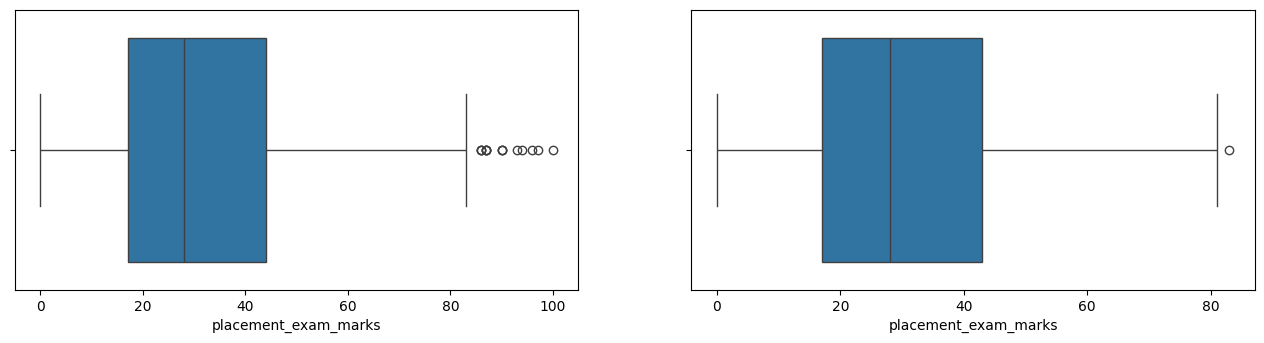

In [46]:
# Comparing

plt.figure(figsize=(16,8))

plt.subplot(2,2,1)
sns.boxplot( x = df['placement_exam_marks'])


plt.subplot(2,2,2)
sns.boxplot( x = new_df['placement_exam_marks'])

plt.show()

In [47]:
new_df_cap = df.copy()

new_df_cap['placement_exam_marks'] = np.where(
    new_df_cap['placement_exam_marks'] > upper_limit,
    upper_limit,
    np.where(
        new_df_cap['placement_exam_marks'] < lower_limit,
        lower_limit,
        new_df_cap['placement_exam_marks']
    )
)

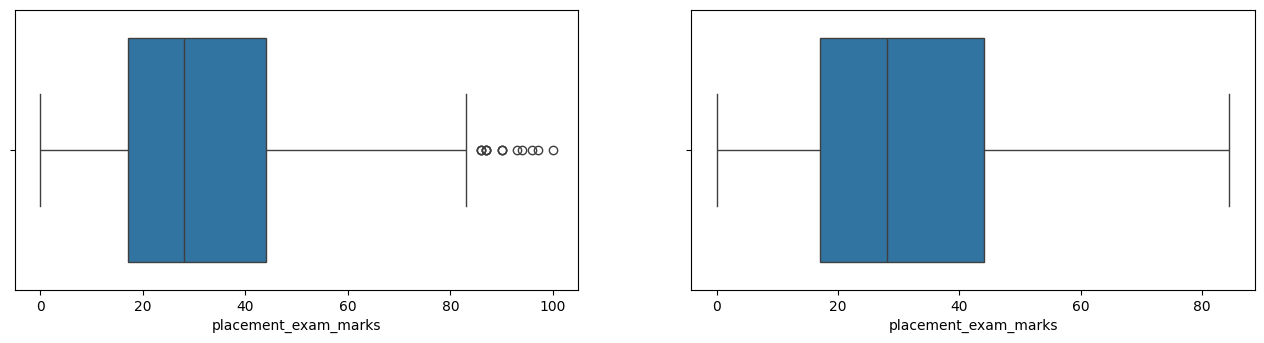

In [51]:
# Comparing

plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.boxplot(x = df['placement_exam_marks'])

plt.subplot(2,2,2)
sns.boxplot( x = new_df_cap['placement_exam_marks'])

plt.show()

 # outlier removal using percentile

In [53]:
df = pd.read_csv('placement.csv')
df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


In [54]:
df['cgpa'].describe()

count    1000.000000
mean        6.961240
std         0.615898
min         4.890000
25%         6.550000
50%         6.960000
75%         7.370000
max         9.120000
Name: cgpa, dtype: float64

<Axes: xlabel='cgpa'>

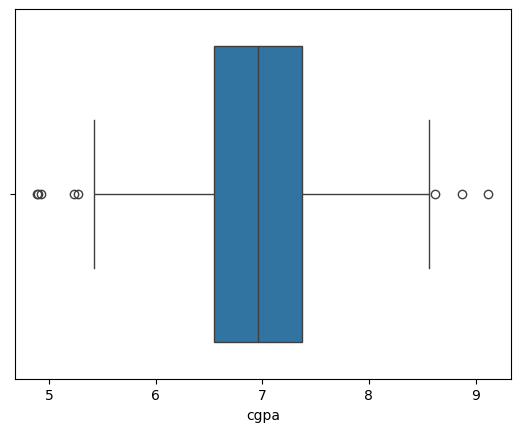

In [56]:
sns.boxplot( x = df['cgpa'])

In [57]:
upper_limit = df['cgpa'].quantile(0.99)
upper_limit

8.4201

In [58]:
lower_limit = df['cgpa'].quantile(0.01)
lower_limit

5.5596

In [60]:
new_df = df[(df['cgpa'] <= 8.4201) & (df['cgpa'] >= 5.5596)]

In [62]:
new_df['cgpa'].describe()

count    980.000000
mean       6.961745
std        0.573327
min        5.560000
25%        6.557500
50%        6.960000
75%        7.360000
max        8.420000
Name: cgpa, dtype: float64

<Axes: xlabel='cgpa'>

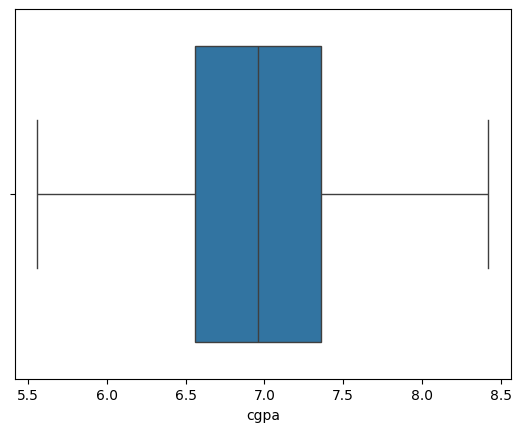

In [64]:
sns.boxplot( x = new_df['cgpa'])

In [65]:
# Capping --> Winsorization
df['cgpa'] = np.where(df['cgpa'] >= upper_limit,
        upper_limit,
        np.where(df['cgpa'] <= lower_limit,
        lower_limit,
        df['cgpa']))

<Axes: xlabel='cgpa'>

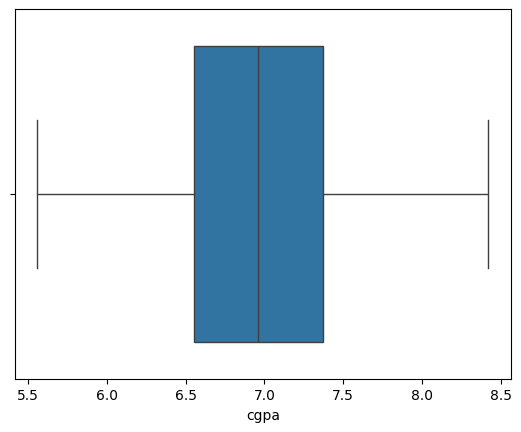

In [67]:
sns.boxplot( x = df['cgpa'])